In [4]:
# Import
import numpy as np
import pandas as pd
import re
import xarray as xr
import matplotlib.pyplot as plt
import datetime, os
from cartopy import crs as ccrs
from cartopy import feature as cfeature

#### Step 1:
- Make sure all LogBook IDs are properly named. We fix variations between logbook names in the logbooks summary csv and the "LogBook ID" column of our log entries field. These discrepancies are caused by: lengty logbook IDs which were truncated in the entries file, variations in capitalization, and date ranges which were entered differently between the logbook and log entries files.
- Calculate summary stats to give an overview of the data contained by each logbook and its origins.

In [5]:
#read in both cleaned datasats - tier 1 and 4
base_dir = os.getcwd()

#Readin in cleaned datasets
export_finalized = {}
for i in range (4):
    print(f"Loaded: {str(os.path.join(base_dir, f'csv_files/Tier{i+1}.csv'))}")
    export_finalized[i+1] = pd.read_csv(os.path.join(base_dir, f'csv_files/Tier{i+1}.csv'), low_memory=False)
    print
    export_finalized[i+1]['Entry Date'] = pd.to_datetime(export_finalized[i+1]['Entry Date'])

Loaded: /home/finn.wimberly/Documents/whaling_logs/20260211_export_2/csv_files/Tier1.csv
Loaded: /home/finn.wimberly/Documents/whaling_logs/20260211_export_2/csv_files/Tier2.csv
Loaded: /home/finn.wimberly/Documents/whaling_logs/20260211_export_2/csv_files/Tier3.csv
Loaded: /home/finn.wimberly/Documents/whaling_logs/20260211_export_2/csv_files/Tier4.csv


In [7]:
#we will use tier 4
tier = 4
df = export_finalized[tier].copy()

#trime df to just necessary final columns
df2= df.drop(columns=['DateTime', 'Entry Date Time',
       'prev_time', 'prev_lat', 'prev_lon', 'delta_time_s', 'dlat_deg',
       'dlon_deg', 'coord_diff', 'Infilled', 'usable', 'gap_distance_km',
       'gap_days_missing', 'gap_type', 'infill_days_missing', 'infill_type',
       'infill_distance_km', 'Tier2_usable', 'Tier3_usable', 'Tier4_usable'])

#df2

In [8]:
trunc_mask = df["LogBook ID"].astype(str).str.contains("…")
trunc_ids = df.loc[trunc_mask, "LogBook ID"].unique()

print(f"There are {len(trunc_ids)} truncated IDs found in the dataset.")

from utils.meta import logbook_id_fix_map

# check that we are correcting all truncations logbook IDs
if len(trunc_ids) != len(logbook_id_fix_map):
    print("WARNING: Number of truncated IDs does NOT match number of entries in logbook_id_fix_map!")
    print(f"  - Truncated IDs found: {len(trunc_ids)}")
    print(f"  - Entries in fix map:   {len(logbook_id_fix_map)}")

    # Extra diagnostics:
    print("\nIDs in the dataset but NOT in your map:")
    missing_from_map = set(trunc_ids) - set(logbook_id_fix_map.keys())
    print(missing_from_map if missing_from_map else "  None")

    print("\nIDs in your map but NOT found in dataset:")
    extra_in_map = set(logbook_id_fix_map.keys()) - set(trunc_ids)
    print(extra_in_map if extra_in_map else "  None")

else:
    print("Mapping length matches the number of truncated IDs.")


There are 30 truncated IDs found in the dataset.
Mapping length matches the number of truncated IDs.


In [9]:
#applying corrections to truncated ID map
df["LogBook ID"] = df["LogBook ID"].replace(logbook_id_fix_map)

In [10]:
#premptively handle gage and cw morgan name truncation
df_split_gage = df.copy()

#identify Gage rows and extract entry year
ghp_trunc = "Gage H. Phillips (Schooner) 18…"
ghp_mask = df_split_gage["LogBook ID"] == ghp_trunc
ghp_years = df_split_gage.loc[ghp_mask, "Entry Date"].dt.year

#apply mask
# 1878–1880 voyage
df_split_gage.loc[ghp_mask & ghp_years.between(1878, 1880), "LogBook ID"] = \
    "Gage H. Phillips (Schooner) 1878-1880"
# 1881–1883 voyage
df_split_gage.loc[ghp_mask & ghp_years.between(1881, 1883), "LogBook ID"] = \
    "Gage H. Phillips (Schooner) 1881-1883"

In [11]:
from utils.meta import standardize_logbook_id

df_clean_strings = df_split_gage.copy()
df_clean_strings["LogBook ID"] = df_clean_strings["LogBook ID"].astype(str).apply(standardize_logbook_id)

In [12]:
date_fix_map =  {"Arab (Ship) 1849-1853" :   "Arab (Ship) 1849-1852",  #REVISING TO MATCH LOGBOOK NAMES (49-52 and 52-53 are separate logbooks)
                #ADDING DATES THAT WERE EXCLUDED IN ENTRIES BUT INCLUDED IN META DATA
                "Brunswick (Ship)"      :   "Brunswick (Ship) 1861-1862",  
                "Catalpa (Bark)"        :   "Catalpa (Bark) 1875-1876",
                "Perry (Bark)"          :   'Perry (Bark) 1877-1880'}

#applying changes
df_clean_strings["LogBook ID"] = df_clean_strings["LogBook ID"].replace(date_fix_map)

In [13]:
df_final = df_clean_strings.copy()

grouped = (
    df_final
    .groupby('LogBook ID')
    .agg(
        Total_Entries = ('LogBook ID', "size"),
        Total_Usable_Entries = ('Tier4_usable', "sum"), 
    )
    .reset_index()
)

summary_df = grouped.copy()
summary_df

,LogBook ID,Total_Entries,Total_Usable_Entries
0,A. Houghton (Bark) 1853-1857,701,469
1,A. M. Nicholson (Schooner) 1909-1910,15,8
2,A. R. Tucker (Bark) 1871-1874,284,138
3,Abigail (Ship) 1847-1850,852,186
4,Abraham Barker (Ship) 1850-1853,807,462
...,...,...,...
194,Xantho (Bark) 1866-1869,48,37
195,Yeoman (Bark) 1843-1848,1499,1110
196,Young Phenix (1867 -1871),1096,917
197,Young Phenix (Ship) 1836-1840,1246,1045


In [14]:
#read in meta data file
meta_df = pd.read_csv(os.path.join(base_dir, f'csv_files/logbooks-export-meta.csv'), low_memory=False)

df = meta_df.copy()
df["LogBook ID"] = df["LogBook ID"].astype(str).apply(standardize_logbook_id)

In [15]:
# rename chilli to match logbook id used in dataset
df.loc[
    df['LogBook ID'] == "Chili (Ship) Captain's Journal 1848-1852", 
    'LogBook ID'
] = "Chili (Ship) 1848-1852"

In [16]:
ID_COL = "LogBook ID"     
RESEARCHER_COL = "Researcher"   
REPOSITORY_COL = "Repository" 

meta_subset = df[[ID_COL, RESEARCHER_COL, REPOSITORY_COL]].copy()

# All duplicated IDs (including the first occurrence)
dupes_all = df[df.duplicated(subset=[ID_COL], keep=False)]

dupes_all.sort_values(by=ID_COL)

# one row per logbook in metadata
meta_subset = meta_subset.drop_duplicates(subset=["LogBook ID"])

In [17]:
standard_repo_map = {'NBWM' : 'New Bedford Whaling Museum',
                     'PPL' : 'Providence Public Library',
                     'Falmouth Museums on the Green' : 'Falmouth Museum on the Green',
                     'Providence Public library' : 'Providence Public Library',
                     'Nicholson Whaling Collection' : 'Providence Public Library',
                     'Nicholson Whaling Collection, Providence Public Library' : 
                                      'Providence Public Library'}

meta_subset[REPOSITORY_COL] = meta_subset[REPOSITORY_COL].replace(standard_repo_map)

In [18]:
summary_with_meta = summary_df.merge(
    meta_subset,
    on="LogBook ID",
    how="left"   # keep all logbooks in summary_df, even if metadata missing
)

#Uncomment to create - just dont need to overwrite every time
summary_with_meta.to_csv(f"csv_files/Tier{tier}logbooks_meta.csv", index=False)
summary_with_meta

,LogBook ID,Total_Entries,Total_Usable_Entries,Researcher,Repository
0,A. Houghton (Bark) 1853-1857,701,469,Abigail Field,New Bedford Whaling Museum
1,A. M. Nicholson (Schooner) 1909-1910,15,8,Timothy Walker,New Bedford Whaling Museum
2,A. R. Tucker (Bark) 1871-1874,284,138,Abigail Field,New Bedford Whaling Museum
3,Abigail (Ship) 1847-1850,852,186,Stephen Luce,Providence Public Library
4,Abraham Barker (Ship) 1850-1853,807,462,Jenny Sullivan,Providence Public Library
...,...,...,...,...,...
194,Xantho (Bark) 1866-1869,48,37,Claudia Gentner,Nantucket Historical Association
195,Yeoman (Bark) 1843-1848,1499,1110,Amanda Cutler,Providence Public Library
196,Young Phenix (1867 -1871),1096,917,Christopher Bice,New Bedford Whaling Museum
197,Young Phenix (Ship) 1836-1840,1246,1045,Stephen Luce,Providence Public Library


In [30]:
# Logbooks in summary_df with no matching metadata
missing_meta = summary_with_meta[summary_with_meta["Researcher"].isna() &
                                 summary_with_meta["Repository"].isna()]

if not missing_meta.empty:
    print("No metadata found for these LogBook IDs:")
    print(missing_meta["LogBook ID"].to_list())
else:
    print("All LogBook IDs in summary_df have matching metadata.")

# Logbooks in meta_df that never appear in summary_df (optional)
summary_ids = set(summary_df["LogBook ID"])
meta_ids = set(meta_subset["LogBook ID"])

missing_in_dataset = meta_ids - summary_ids
if missing_in_dataset:
    print("These logbooks are currently excluded from the data set:")
    print(list(missing_in_dataset))

All LogBook IDs in summary_df have matching metadata.
These logbooks are currently excluded from the data set:
['Barnstable (Bark) 1860-1864', 'Amazon (Bark) 1856-1860', 'Napoleon (Bark) 1868-1872', 'Alert (Ship) 1845-1847', 'Westward- 1978', 'Catherwood (Bark) 1853-1854', 'William (Brig) 1838', 'Albion (Ship) 1842-1844', 'TEST LOG BOOK NAME', 'Margaret (Ship) 1835-1836', 'Norman (Ship) 1855-1860', 'Alaska (Bark) 1880-1884', 'Mercator (Ship) 1840-1843', 'Scotland (Bark) 1857-1860', 'Congress (Ship) 1857-1859', 'Jason (Ship) 1846-1848', 'Herald (Ship) 1834-1837', 'Hibernia (Ship)', 'Adeline Gibbs (Bark) 1880-1885', 'Albion (Ship) 1844-1845', 'Charles W. Morgan (Ship) 1841-1845 Journal', 'Congress (1857-1859)', 'President (Bark) 1865-1869', 'Alexander Barclay (Ship) 1837-1838 journal', 'Lapwing (Ship) 1860-1863', 'Young Phoenix (Ship) 1840-1844', 'Lancer (Ship) 1865-1868', 'Young Phoenix (1840-1844)', 'Young Phoenix (Ship) 1830-1836', 'Leonidas (ship) Journal 1830-1833', 'TEST TEST HG JU

#### Step 2:
- Generate library of visualizations for each voyage as well as the combined dataset (all voyages combined). These will be attached to the summary stats table.

In [20]:
from utils.meta import plot_logbook_with_options

#select dataframe to plot from
tier = 4
plot_df = df_final.copy()

#select logbook to plot
selected_logbook = 'A. Houghton (Bark) 1853-1857'

cwd = os.getcwd()

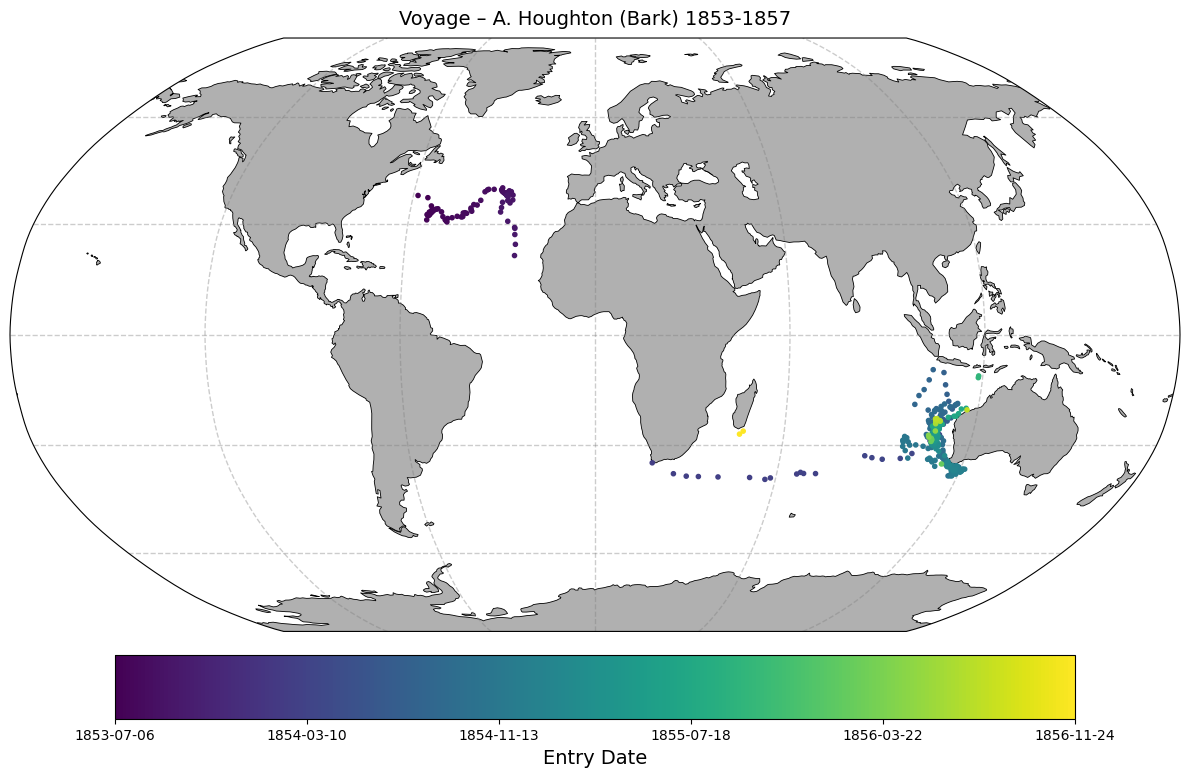

(<Figure size 1200x800 with 2 Axes>,
 <GeoAxes: title={'center': 'Voyage – A. Houghton (Bark) 1853-1857'}>)

In [21]:
#single logbook inspection

plot_logbook_with_options(plot_df, selected_logbook, save=False, color_by = 'Entry Date',  title=f'Voyage – {selected_logbook}', plot_path=False)

In [22]:
#plot_logbook_with_options(plot_df, selected_logbook, save=False, color_by = 'green', plot_path = False, title=f'Voyage – {selected_logbook}')

In [24]:
#create all figs
logbook_list = plot_df['LogBook ID'].unique().tolist()
logbooks_to_rm = ['Ann (Ship) 1841', 'Ann (Ship) 1791-1792', 'Sea Breeze (1865 - 1871)'] #these contain no valid entries

for logbook in logbooks_to_rm:
    if logbook in logbook_list:
        logbook_list.remove(logbook)

save_dir = os.path.join(cwd, "meta_figs/single_voyages/voyage_progress")
os.makedirs(save_dir, exist_ok=True)

for logbook in logbook_list:
    plot_logbook_with_options(plot_df, logbook, save=True, save_path = save_dir, selected_tier = tier, color_by = 'Entry Date', plot_path=False, title=f'Voyage – {logbook}')

In [25]:
save_dir = os.path.join(cwd, "meta_figs/single_voyages/wind_force")
os.makedirs(save_dir, exist_ok=True)

for logbook in logbook_list:
    plot_logbook_with_options(plot_df, logbook, save=True, save_path = save_dir, selected_tier = tier, color_by = 'BF Value', plot_path=False, title=f'Wind Force Values – {logbook}')

In [26]:
from utils.meta import plot_all_logbooks_with_options

In [27]:
save_dir = os.path.join(cwd, "meta_figs/combined_voyages")
os.makedirs(save_dir, exist_ok=True)

plot_all_logbooks_with_options(plot_df, save=True, save_path = save_dir, selected_tier = tier, color_by = 'BF Value', title=f'Wind Force Values – All Usable Entries')

(<Figure size 1200x800 with 2 Axes>,
 <GeoAxes: title={'center': 'Wind Force Values – All Usable Entries'}>)

In [28]:
plot_all_logbooks_with_options(plot_df, save=True, save_path = save_dir, selected_tier = tier, color_by = 'WD_Bearing', title=f'Wind Bearing – All Usable Entries')

(<Figure size 1200x800 with 2 Axes>,
 <GeoAxes: title={'center': 'Wind Bearing – All Usable Entries'}>)

In [29]:
#sync all figs and csv to Drive
!utils/sync_metadata.sh 